# Univariate Analysis

## Objective

The objective of this notebook is to perform univariate analysis on each feature in the Telco Customer Churn dataset.

Univariate analysis focuses on understanding the characteristics of individual variables without considering relationships with other variables.

For each feature, we will examine:

- Distribution
- Frequency
- Central tendency (for numerical variables)
- Spread and variability
- Potential skewness
- Business interpretation
- Machine learning relevance

The insights obtained from this notebook will help us understand the customer base before analyzing relationships between variables and customer churn.

## Section 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")

## Section 2 — Load Dataset

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

## Section 3 — Basic Verification

In [3]:
print(f"Dataset Shape : {df.shape}")

display(df.head())

df.info()

Dataset Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Section 4 — Separate Feature Types

In [4]:
# Numerical Features

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


# Categorical Features

categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()


print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [5]:
categorical_features.remove("customerID")

In [6]:
print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


## Section 5 — Dataset Summary Table

In [7]:
summary = pd.DataFrame({

    "Data Type": df.dtypes,

    "Missing Values": df.isnull().sum(),

    "Unique Values": df.nunique()

})

summary

,Data Type,Missing Values,Unique Values
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


## Section 6 – Helper Functions

### Helper Functions

To avoid repetitive code and improve maintainability, we create reusable helper functions for common analysis tasks.

Each helper function has a single responsibility and will later be combined into higher-level feature analysis functions.

In [ ]:
# Helper Function 1

def display_basic_info(df, column):
    """
    Display basic information about a feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Feature name.
    """

    print("=" * 60)
    print(f"Feature : {column}")
    print("=" * 60)

    print(f"Data Type          : {df[column].dtype}")
    print(f"Missing Values     : {df[column].isnull().sum()}")

    missing_percentage = (
        df[column].isnull().sum() / len(df)
    ) * 100

    print(f"Missing Percentage : {missing_percentage:.2f}%")

    print(f"Unique Values      : {df[column].nunique()}")

In [9]:
display_basic_info(df, "tenure")

Feature : tenure
Data Type          : int64
Missing Values     : 0
Missing Percentage : 0.00%
Unique Values      : 73


In [10]:
display_basic_info(df, "Contract")

Feature : Contract
Data Type          : object
Missing Values     : 0
Missing Percentage : 0.00%
Unique Values      : 3


Why Didn't We Return Anything?

Notice our function only prints information.

That's intentional.

At this stage, we're creating display functions, not data-processing functions.

Later, when we move these utilities into src/utils, we might modify them to return dictionaries or DataFrames. But for an exploratory notebook, printing keeps the output readable.

In [12]:
# Helper Function 2

def display_summary_statistics(df, column):
    """
    Display descriptive statistics for a numerical feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.
    """

    summary = pd.DataFrame({
        "Statistic": [
            "Count",
            "Mean",
            "Median",
            "Mode",
            "Standard Deviation",
            "Minimum",
            "25th Percentile (Q1)",
            "50th Percentile (Median)",
            "75th Percentile (Q3)",
            "Maximum",
            "Variance"
        ],
        "Value": [
            df[column].count(),
            df[column].mean(),
            df[column].median(),
            df[column].mode()[0],
            df[column].std(),
            df[column].min(),
            df[column].quantile(0.25),
            df[column].quantile(0.50),
            df[column].quantile(0.75),
            df[column].max(),
            df[column].var()
        ]
    })

    display(summary)

In [14]:
display_summary_statistics(df, "MonthlyCharges")

,Statistic,Value
0,Count,7043.000000
1,Mean,64.761692
2,Median,70.350000
3,Mode,20.050000
4,Standard Deviation,30.090047
5,Minimum,18.250000
6,25th Percentile (Q1),35.500000
7,50th Percentile (Median),70.350000
8,75th Percentile (Q3),89.850000
9,Maximum,118.750000


Why Use Our Own Summary Instead of describe()?

describe() is useful, but it has limitations:

It doesn't show the mode.
It doesn't include the variance.
The row labels are generic.
It's less presentation-friendly.

Our custom summary:

Is easier to read.
Has explicit labels.
Can be extended later (e.g., add skewness, kurtosis).

### Helper Function 3: Distribution Plot

This helper function visualizes the distribution of a numerical feature using a histogram and Kernel Density Estimation (KDE).

The plot also highlights the **mean** and **median** to provide a quick understanding of the feature's central tendency and distribution shape.

In [15]:
# Helper Function 3 – Distribution Plot

def plot_distribution(df, column):
    """
    Plot the distribution of a numerical feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.
    """

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        color="steelblue",
        edgecolor="black",
        alpha=0.7
    )

    mean_value = df[column].mean()
    median_value = df[column].median()

    plt.axvline(
        mean_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean : {mean_value:.2f}"
    )

    plt.axvline(
        median_value,
        color="green",
        linestyle="-.",
        linewidth=2,
        label=f"Median : {median_value:.2f}"
    )

    plt.title(f"Distribution of {column}", fontsize=14, fontweight="bold")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

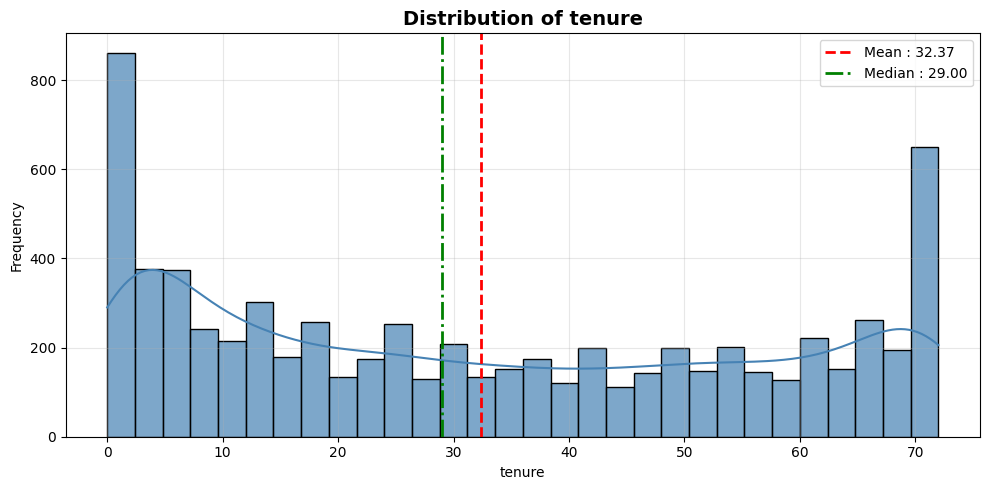

In [16]:
plot_distribution(df, "tenure")

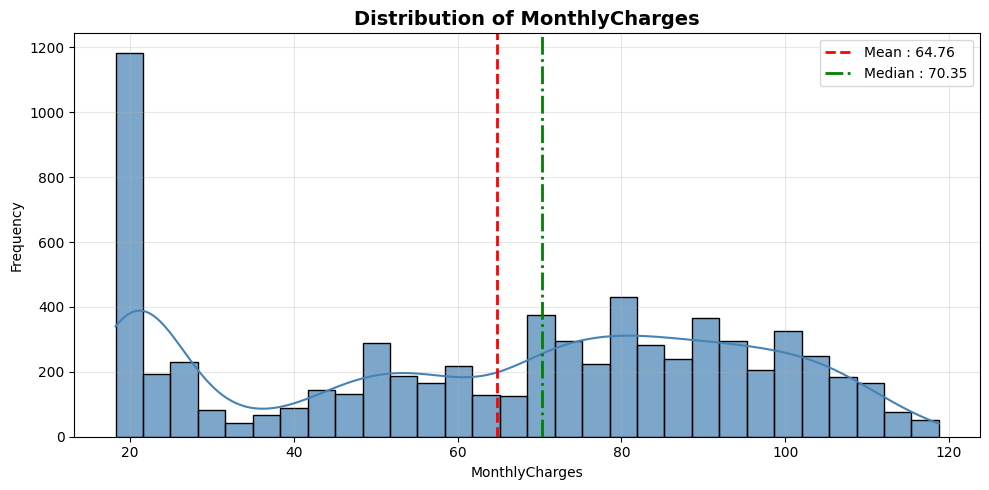

In [17]:
plot_distribution(df, "MonthlyCharges")

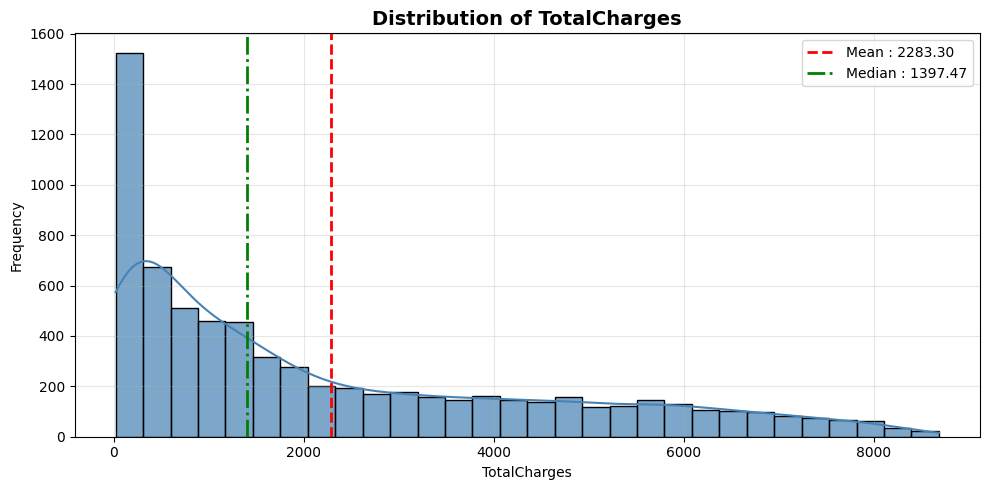

In [18]:
plot_distribution(df, "TotalCharges")

### Helper Function 4: Boxplot

This helper function visualizes a numerical feature using a boxplot.

A boxplot summarizes the distribution by displaying:

- Median
- First Quartile (Q1)
- Third Quartile (Q3)
- Interquartile Range (IQR)
- Potential outliers

It complements the histogram by providing a concise statistical summary of the feature.

In [31]:
def plot_boxplot(df, column):
    """
    Plot a boxplot for a numerical feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.
    """

    plt.figure(figsize=(10, 2))

    # sns.boxplot(
    #     data=df,
    #     x=column,
    #     color="skyblue",
    #     linewidth=1.5,
    #     fliersize=5
    # )

    sns.boxplot(
        data=df,
        x=column,
        color="skyblue",
        linewidth=1.5,
        fliersize=5,
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
            "markersize": 7
        }
    )

    plt.title(
        f"Boxplot of {column}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(column)

    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    plt.show()

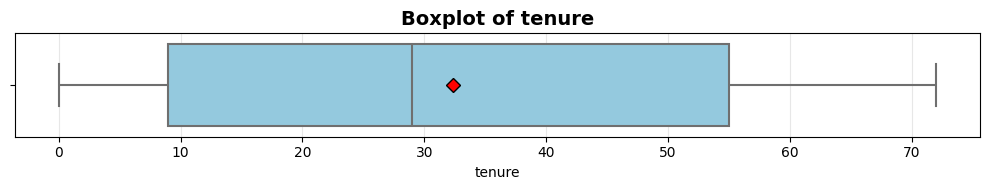

In [32]:
plot_boxplot(df, "tenure")

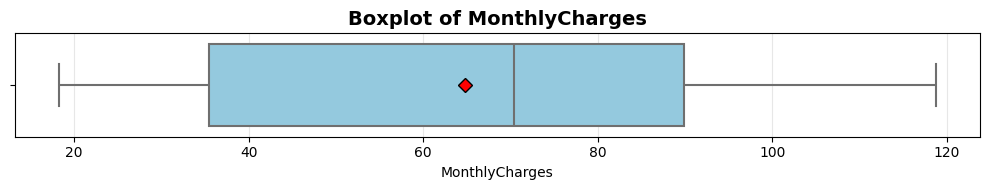

In [33]:
plot_boxplot(df, "MonthlyCharges")

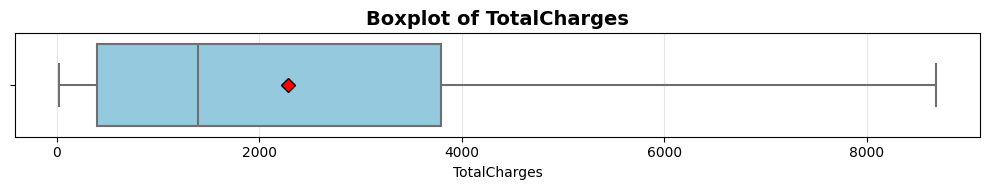

In [34]:
plot_boxplot(df, "TotalCharges")

### Helper Function 5: Skewness Analysis

Skewness measures the asymmetry of a distribution around its mean.

Interpretation:

- **Skewness ≈ 0** → Approximately Symmetric
- **Skewness > 0** → Positively (Right) Skewed
- **Skewness < 0** → Negatively (Left) Skewed

Understanding skewness helps identify whether a feature may require transformation before model training.

In [35]:
def analyze_skewness(df, column):
    """
    Calculate and interpret the skewness of a numerical feature.
    """

    skewness = df[column].skew()

    print("=" * 60)
    print("Skewness Analysis")
    print("=" * 60)

    print(f"Skewness Value : {skewness:.3f}")

    if abs(skewness) < 0.5:
        interpretation = "Approximately Symmetric"
        implication = "No transformation is generally required."

    elif 0.5 <= skewness < 1:
        interpretation = "Moderately Positively Skewed"
        implication = "Feature transformation may improve some models."

    elif skewness >= 1:
        interpretation = "Highly Positively Skewed"
        implication = "Consider log, Box-Cox, or Yeo-Johnson transformation."

    elif -1 < skewness <= -0.5:
        interpretation = "Moderately Negatively Skewed"
        implication = "Transformation may be beneficial depending on the model."

    else:
        interpretation = "Highly Negatively Skewed"
        implication = "Consider suitable transformation techniques."

    print(f"Distribution : {interpretation}")
    print(f"ML Insight   : {implication}")

In [36]:
analyze_skewness(df, "tenure")

Skewness Analysis
Skewness Value : 0.240
Distribution : Approximately Symmetric
ML Insight   : No transformation is generally required.


In [37]:
analyze_skewness(df, "MonthlyCharges")

Skewness Analysis
Skewness Value : -0.221
Distribution : Approximately Symmetric
ML Insight   : No transformation is generally required.


In [38]:
analyze_skewness(df, "TotalCharges")

Skewness Analysis
Skewness Value : 0.962
Distribution : Moderately Positively Skewed
ML Insight   : Feature transformation may improve some models.


### Master Function: Numerical Feature Analysis

This function combines all numerical analysis helper functions into a single workflow.

For a given numerical feature, it performs:

1. Basic Information
2. Summary Statistics
3. Distribution Plot
4. Boxplot
5. Skewness Analysis

This modular approach avoids repetitive code and makes the notebook easier to maintain and extend.

In [39]:
def analyze_numerical_feature(df, column):
    """
    Perform a complete univariate analysis
    for a numerical feature.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.

    column : str
        Numerical feature name.
    """

    print("\n")
    print("=" * 80)
    print(f"NUMERICAL FEATURE ANALYSIS : {column.upper()}")
    print("=" * 80)

    # Basic Information
    display_basic_info(df, column)

    print("\n")

    # Summary Statistics
    display_summary_statistics(df, column)

    print("\n")

    # Distribution Plot
    plot_distribution(df, column)

    # Boxplot
    plot_boxplot(df, column)

    # Skewness
    analyze_skewness(df, column)

    print("\n")
    print("=" * 80)
    print("Analysis Completed")
    print("=" * 80)